# **IMDb Top 1000 Movies Dataset Analysis 🎬**

This notebook presents comprehensive Exploratory Data Analysis (EDA) of an IMDb movie dataset. It consists of three main parts: Data Cleaning Part, Exploratory Data Analysis Part, Additional Observations and Summary.

*   Python script uses Pandas, NumPy libraries for data cleaning and manipulation, and statistical aggregation, as well as Seaborn and Matplotlib for data vizualisation (including histograms, box plots, scatter plots, line charts and heatmaps).
*   Statistical analysis (correlation, IQR) was applied to quantify relationships within dataset and identify data anomalies.

# **I. Data Cleaning Part**

**1. Import all required libraries to access CSV file on Drive, read, clean and analyse it, and present the results.**

In [1]:
pip install scikit-posthocs

In [2]:
from google.colab import drive
from scipy import stats
from scipy.stats import shapiro, normaltest
import scikit_posthocs as sp

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import plotly.express as px

plt.style.use('ggplot')
pd.set_option('display.max_columns', 50)

**2. Create custom functions to use in the script.**

In [3]:
def millions_formatter(x, pos):
    if abs(x) >= 1000000:
        return f'{x / 1000000:1.1f}M'

    return f'{x:,.0f}'

formatter = ticker.FuncFormatter(millions_formatter)

**3. Mount Google Drive and define the path to the CSV file.**

In [4]:
drive.mount('/content/drive')
file_path = '/content/drive/My Drive/imdb_top_1000.csv'

Mounted at /content/drive


**4. Read and inspect CSV file.**

In [5]:
try:
    initial_df = pd.read_csv(file_path, header=0)
    print("Dataframe shape - number of rows and columns:")
    print(initial_df.shape)
    print()
    print("Initial Dataframe Head:")
    print(initial_df.head())
    print()
    print("\nInitial Dataframe Columns:")
    print(initial_df.columns)
    print()
    print("\nInitial Dataframe Info:")
    print(initial_df.info())
except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}. Please check the path and try again.")
    exit()

Dataframe shape - number of rows and columns:
(1000, 16)

Initial Dataframe Head:
                                         Poster_Link  \
0  https://m.media-amazon.com/images/M/MV5BMDFkYT...   
1  https://m.media-amazon.com/images/M/MV5BM2MyNj...   
2  https://m.media-amazon.com/images/M/MV5BMTMxNT...   
3  https://m.media-amazon.com/images/M/MV5BMWMwMG...   
4  https://m.media-amazon.com/images/M/MV5BMWU4N2...   

               Series_Title Released_Year Certificate  Runtime  \
0  The Shawshank Redemption          1994           A  142 min   
1             The Godfather          1972           A  175 min   
2           The Dark Knight          2008          UA  152 min   
3    The Godfather: Part II          1974           A  202 min   
4              12 Angry Men          1957           U   96 min   

                  Genre  IMDB_Rating  \
0                 Drama          9.3   
1          Crime, Drama          9.2   
2  Action, Crime, Drama          9.0   
3          Crime, Drama 

**5. Create a copy of initial dataframe to work with.**

In [6]:
df = initial_df.copy()

**6. Check if there are duplicate rows.**

In [7]:
duplicated_rows = df[df.duplicated(keep=False)]
print(duplicated_rows)

Empty DataFrame
Columns: [Poster_Link, Series_Title, Released_Year, Certificate, Runtime, Genre, IMDB_Rating, Overview, Meta_score, Director, Star1, Star2, Star3, Star4, No_of_Votes, Gross]
Index: []


**Note:** Empty DataFrame means that there are no full duplicate rows.

**7. Check for duplicates by "Series_Title" (movie name) column**.

In [8]:
duplicate_title_rows = df[df['Series_Title'].duplicated(keep=False)]
print(duplicate_title_rows)

                                           Poster_Link Series_Title  \
87   https://m.media-amazon.com/images/M/MV5BYmY3Mz...     Drishyam   
136  https://m.media-amazon.com/images/M/MV5BYmJhZm...     Drishyam   

    Released_Year Certificate  Runtime                   Genre  IMDB_Rating  \
87           2013           U  160 min  Crime, Drama, Thriller          8.3   
136          2015          UA  163 min   Crime, Drama, Mystery          8.2   

                                              Overview  Meta_score  \
87   A man goes to extreme lengths to save his fami...         NaN   
136  Desperate measures are taken by a man who trie...         NaN   

            Director       Star1         Star2         Star3         Star4  \
87     Jeethu Joseph    Mohanlal         Meena  Asha Sharath        Ansiba   
136  Nishikant Kamat  Ajay Devgn  Shriya Saran          Tabu  Rajat Kapoor   

     No_of_Votes    Gross  
87         30722      NaN  
136        70367  739,478  


**Note:** Check showed that 2 movies in dataset have same names, but since other values are different, both rows are kept.

**8. Remove unnecessary columns.**

In [9]:
df = df.drop(['Poster_Link', 'Overview'], axis=1)

**9. Split "Genre" column's values into separate columns.**

In [10]:
new_columns = df['Genre'].str.split(', ', expand=True)
new_columns.columns = [f'Genre_{i+1}' for i in range(new_columns.shape[1])]
df = pd.concat([df, new_columns], axis=1)
df = df.drop('Genre', axis=1)

**10. Handle missing data.**
*  Columns "Certificate", "Meta_score" and "Gross" have missing values.
*  Since 'float64' dtype accepts NaNs the "Meta_score" column is not changed.

* **Fill the missing values in the "Certificate" column with "Unknown".**

In [11]:
df['Certificate'] = df['Certificate'].fillna('Unknown')

*  **Remove commas in the "Gross" column values to be able to change its dtype to 'int'.**

In [12]:
df['Gross'] = df['Gross'].str.replace(',', '')

*  **Change dtype of the "Gross" column to 'Int64'.**
*  **This would keep NaN values in place, but convert others to 'int' for calculations.**
*  **Check that NaN are preserved.**

In [13]:
df['Gross'] = df['Gross'].astype('Int64')
df['Gross'].isna().sum()

np.int64(169)

**11. Check values and update datatypes of columns.**

*   **Convert columns with text as values to 'string' dtype.**

In [14]:
convert_to_string = ['Series_Title', 'Certificate', 'Genre_1', 'Genre_2', 'Genre_3', 'Director', 'Star1', 'Star2', 'Star3', 'Star4']
df[convert_to_string] = df[convert_to_string].astype('string')

*   **Check for anomalities in "Released_Year" column.**

In [15]:
df['Released_Year'].unique()

array(['1994', '1972', '2008', '1974', '1957', '2003', '1993', '2010',
       '1999', '2001', '1966', '2002', '1990', '1980', '1975', '2020',
       '2019', '2014', '1998', '1997', '1995', '1991', '1977', '1962',
       '1954', '1946', '2011', '2006', '2000', '1988', '1985', '1968',
       '1960', '1942', '1936', '1931', '2018', '2017', '2016', '2012',
       '2009', '2007', '1984', '1981', '1979', '1971', '1963', '1964',
       '1950', '1940', '2013', '2005', '2004', '1992', '1987', '1986',
       '1983', '1976', '1973', '1965', '1959', '1958', '1952', '1948',
       '1944', '1941', '1927', '1921', '2015', '1996', '1989', '1978',
       '1961', '1955', '1953', '1925', '1924', '1982', '1967', '1951',
       '1949', '1939', '1937', '1934', '1928', '1926', '1920', '1970',
       '1969', '1956', '1947', '1945', '1930', '1938', '1935', '1933',
       '1932', '1922', '1943', 'PG'], dtype=object)

*   **Find out, which row includes 'PG' as "Released_Year".**

In [16]:
pg_year = df[df['Released_Year'] == 'PG']
print(pg_year)

    Series_Title Released_Year Certificate  Runtime  IMDB_Rating  Meta_score  \
966    Apollo 13            PG           U  140 min          7.6        77.0   

       Director      Star1        Star2        Star3        Star4  \
966  Ron Howard  Tom Hanks  Bill Paxton  Kevin Bacon  Gary Sinise   

     No_of_Votes      Gross    Genre_1 Genre_2  Genre_3  
966       269197  173837933  Adventure   Drama  History  


*  **Replace "PG" with actual "Apollo 13" release year.**

In [17]:
df['Released_Year'] = df['Released_Year'].str.replace('PG', '1995')

*  **Convert the 'Released_Year' column to 'datetime' object.**

In [18]:
df['Released_Year'] = df['Released_Year'].astype('int')

*  **Check unique value is "Runtime" column.**

In [19]:
df['Runtime'].unique()

array(['142 min', '175 min', '152 min', '202 min', '96 min', '201 min',
       '154 min', '195 min', '148 min', '139 min', '178 min', '161 min',
       '179 min', '136 min', '146 min', '124 min', '133 min', '160 min',
       '132 min', '153 min', '169 min', '130 min', '125 min', '189 min',
       '116 min', '127 min', '118 min', '121 min', '207 min', '122 min',
       '106 min', '112 min', '151 min', '150 min', '155 min', '119 min',
       '110 min', '88 min', '137 min', '89 min', '165 min', '109 min',
       '102 min', '87 min', '126 min', '147 min', '117 min', '181 min',
       '149 min', '105 min', '164 min', '170 min', '98 min', '101 min',
       '113 min', '134 min', '229 min', '115 min', '143 min', '95 min',
       '104 min', '123 min', '131 min', '108 min', '81 min', '99 min',
       '114 min', '129 min', '228 min', '128 min', '103 min', '107 min',
       '68 min', '138 min', '156 min', '167 min', '163 min', '186 min',
       '321 min', '135 min', '140 min', '180 min', '158 min'

*  **Split values in "Runtime" column and keep only numbers. Rename the column for clarity to "Runtime_minutes" and change its dtype to 'int'.**

In [20]:
df['Runtime'] = df['Runtime'].str.split(' ').str[0]
df.rename(columns={'Runtime': 'Runtime_minutes'}, inplace=True)
df['Runtime_minutes'] = df['Runtime_minutes'].astype('int64')

*   **Check that all datatypes are now updated.**

In [21]:
df.dtypes

,0
Series_Title,string[python]
Released_Year,int64
Certificate,string[python]
Runtime_minutes,int64
IMDB_Rating,float64
Meta_score,float64
Director,string[python]
Star1,string[python]
Star2,string[python]
Star3,string[python]


*  **Check unique values of "Certificate" column.**

In [22]:
df['Certificate'].unique()

<StringArray>
[       'A',       'UA',        'U',    'PG-13',        'R',  'Unknown',
       'PG',        'G',   'Passed',    'TV-14',       '16',    'TV-MA',
  'Unrated',       'GP', 'Approved',    'TV-PG',      'U/A']
Length: 17, dtype: string

* This result shows that the "Certificate" column isn't clean and its values can be homogenised according to IMDb guidelines:

**Unrestricted:**
- 'G' : General
- 'U' : Universal, suitable for all
- 'TV-G' : General for TV.

**Parental Guidance:**
- 'PG' : Parental Guidance Suggested (for kids under 10 y.o.).
- 'GP' : older version for Parental Guidance.
- 'UA' and 'U/A' : Parental Guidance Suggested for children.
- 'TV-PG', 'PG-13' : Parental Guidance Suggested for children under 13 y.o.
- 'TV-14' : Parents Strongly Cautioned, program contains content unsuitable for children under 14 y.o.
- 'R' : Under 17 not admitted without an adult.

**Restricted:**
- '16' : Restricted, viewers must be at least 16 y.o.
- 'A', 'TV-MA': Restricted to adults only.

**Other:**
- 'Approved' : pre-1968 titles only under the Hays Code (moral/immoral).
- 'Passed' : a particular rating was assigned.

In [23]:
certificate_map = {
    # 'Unrestricted' Group
    'G': 'Unrestricted',
    'U': 'Unrestricted',

    # 'Parental_Guidance' Group
    'GP': 'Parental_Guidance',
    'UA': 'Parental_Guidance',
    'U/A': 'Parental_Guidance',
    'TV-PG': 'Parental_Guidance',
    'TV-14': 'Parental_Guidance',
    'PG-13': 'Parental_Guidance',
    'PG': 'Parental_Guidance',

    # 'Under 17 supervised' Group
    'R': 'Under_17_Supervised',

    # '16+' Group
    '16': '16+',

    # 'Adults Only' Group
    'A': 'Adults_Only',
    'TV-MA': 'Adults_Only',

    # 'Unknown'
    'Unknown': 'Unknown',

    # 'Passed'
    'Passed': 'Passed',

    # 'Approved':
    'Approved': 'Approved',

    # 'Unrated':
    'Unrated': 'Unrated'
}

df['Grouped_Certificate'] = df['Certificate'].map(certificate_map)

*  **Move "Grouped_Certificate" column to a position next after "Certificate" column.**

In [24]:
move_column = df['Grouped_Certificate']
df = df.drop(columns=['Grouped_Certificate'])
df.insert(loc=3, column='Grouped_Certificate', value=move_column)

*  **Check updated DataFrame.**

In [25]:
df.head()

,Series_Title,Released_Year,Certificate,Grouped_Certificate,Runtime_minutes,IMDB_Rating,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross,Genre_1,Genre_2,Genre_3
0,The Shawshank Redemption,1994,A,Adults_Only,142,9.3,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,28341469,Drama,<NA>,<NA>
1,The Godfather,1972,A,Adults_Only,175,9.2,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,134966411,Crime,Drama,<NA>
2,The Dark Knight,2008,UA,Parental_Guidance,152,9.0,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,534858444,Action,Crime,Drama
3,The Godfather: Part II,1974,A,Adults_Only,202,9.0,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,57300000,Crime,Drama,<NA>
4,12 Angry Men,1957,U,Unrestricted,96,9.0,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,4360000,Crime,Drama,<NA>


*   **Check dataset's "Director" column for inconsistencies.**

In [26]:
MIN_LENGTH = 10

short_names_df = df[df['Director'].str.len() < MIN_LENGTH]

print(f"Directors with names shorter than {MIN_LENGTH} characters:")
print(short_names_df[['Director']].drop_duplicates())

Directors with names shorter than 10 characters:
      Director
40   Tony Kaye
54   Can Ulkay
55     Gayatri
231  Sean Penn
252  Joel Coen
295  John Ford
367  Brad Bird
403  Spike Lee
413  Hal Ashby
468  Ken Loach
471  Matt Ross
498    Ang Lee
531  Bob Clark
534  Bob Fosse
565   Sam Wood
576  Paul King
592   Don Hall
666   John Woo
678  Sam Raimi
754  Marc Webb
798   Bob Gale
825  Jon Avnet
855  Gene Saks
924   Ronny Yu
932  James Wan
949  Ted Demme
972  Marc Caro


*  There is problem with raw 55.

*   **Check dataset's "Stars1" column for inconsistencies.**

In [27]:
MIN_LENGTH = 10

short_names_df = df[df['Star1'].str.len() < MIN_LENGTH]

print(f"Directors with names shorter than {MIN_LENGTH} characters:")
print(short_names_df[['Star1']].drop_duplicates())

Directors with names shorter than 10 characters:
         Star1
3    Al Pacino
9    Brad Pitt
11   Tom Hanks
20      Suriya
42   Jean Reno
54   Erdem Can
55     Pushkar
59   Joe Russo
66   Ben Burtt
87    Mohanlal
130       Yash
134    Prabhas
144  Tom Hardy
163  Sener Sen
232  Joel Coen
249   Tim Roth
262  Sam Neill
265    Gong Li
328  Dev Patel
337  Iko Uwais
375   Alan Mak
384      Björk
401  Kirk Wise
422      Topol
454  Myrna Loy
461  Lew Ayres
476  Amy Adams
497   Lee Pace
505  Sean Penn
507     Jet Li
519  Rena Owen
571  Riz Ahmed
594    Sridevi
605    Won Bin
660  Tom Guiry
680  Tom Waits
735  Amit Sadh
744  Phil Lord
770  Sam Riley
814   Leon Lai
831  John Lone
850  Bruce Lee
878   John Cho
903  Lady Gaga
950   Jude Law
970  Joe Pesci
971  Miki Imai


*   Rows no. 20, 55, 130, 134, 422, and 594 require further inspection.

In [28]:
print(df.iloc[[20, 55, 87, 130, 422, 594]])

            Series_Title  Released_Year Certificate Grouped_Certificate  \
20       Soorarai Pottru           2020           U        Unrestricted   
55          Vikram Vedha           2017          UA   Parental_Guidance   
87              Drishyam           2013           U        Unrestricted   
130     K.G.F: Chapter 1           2018          UA   Parental_Guidance   
422  Fiddler on the Roof           1971           G        Unrestricted   
594     English Vinglish           2012           U        Unrestricted   

     Runtime_minutes  IMDB_Rating  Meta_score        Director     Star1  \
20               153          8.6         NaN   Sudha Kongara    Suriya   
55               147          8.4         NaN         Gayatri   Pushkar   
87               160          8.3         NaN   Jeethu Joseph  Mohanlal   
130              156          8.2         NaN  Prashanth Neel      Yash   
422              181          8.0        67.0  Norman Jewison     Topol   
594              134    

*   **Fix director's and actors' names in record no. 55.**

In [29]:
df['Director'] = df['Director'].str.replace('Gayatri', 'Pushkar–Gayathri')
df['Star1'] = df['Star1'].str.replace('Pushkar', 'Ranganathan Madhavan')
df['Star2'] = df['Star2'].str.replace('Madhavan', 'Vijay Sethupathi')
df['Star3'] = df['Star3'].str.replace('Vijay Sethupathi', 'Shraddha Srinath')
df['Star4'] = df['Star4'].str.replace('Shraddha Srinath', 'Kathir')

*  **Check for outliers in numerical columns.**

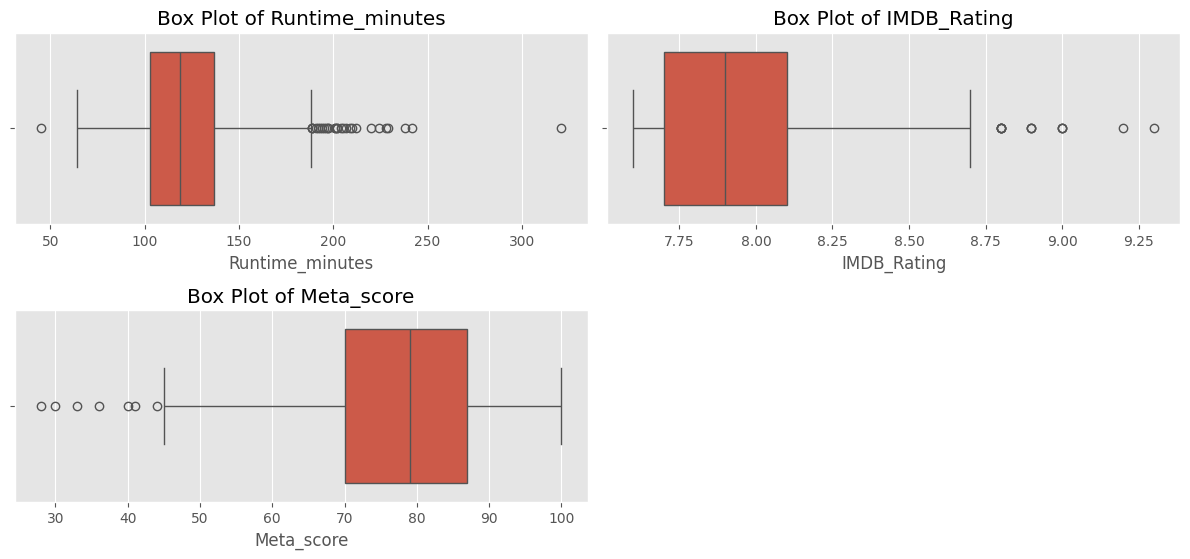

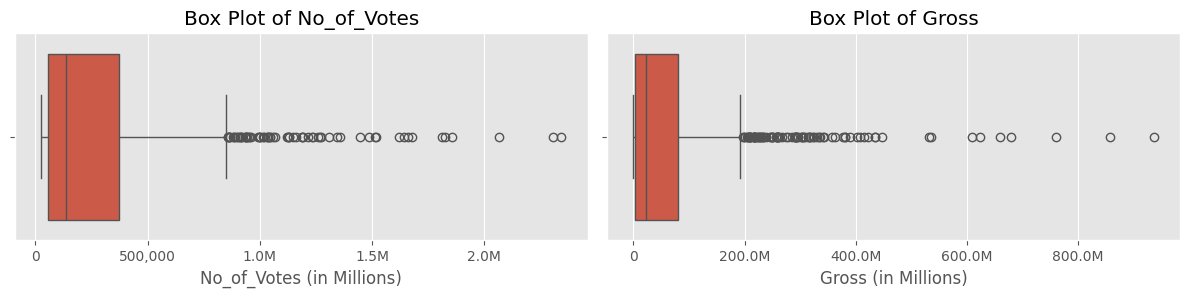

--- IQR Outlier Detection Summary ---

Runtime_minutes:
  Lower Bound: 52.00
  Upper Bound: 188.00
  Total Outliers: 29

IMDB_Rating:
  Lower Bound: 7.10
  Upper Bound: 8.70
  Total Outliers: 13

Meta_score:
  Lower Bound: 44.50
  Upper Bound: 112.50
  Total Outliers: 7

No_of_Votes:
  Lower Bound: -422,426.25
  Upper Bound: 852,113.75
  Total Outliers: 67

Gross:
  Lower Bound: -112,992,442.75
  Upper Bound: 196,996,895.25
  Total Outliers: 89


In [30]:
numerical_cols = ['Runtime_minutes', 'IMDB_Rating', 'Meta_score', 'No_of_Votes', 'Gross']
num_cols = ['Runtime_minutes', 'IMDB_Rating', 'Meta_score']
num_cols_mln = ['No_of_Votes', 'Gross']


plt.figure(figsize=(12, 8))

for i, col in enumerate(num_cols):
    plt.subplot(3, 2, i + 1)

    sns.boxplot(x=df[col].dropna())

    plt.title(f'Box Plot of {col}')

    plt.xlabel(col)
    plt.ylabel('')

plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 8))
fig = plt.gcf()
for i, col in enumerate(num_cols_mln):
    ax = fig.add_subplot(3, 2, i + 1)

    sns.boxplot(x=df[col].dropna(), ax=ax)
    ax.xaxis.set_major_formatter(formatter)

    plt.title(f'Box Plot of {col}')
    plt.xlabel(f'{col} (in Millions)')
    plt.ylabel('')

plt.tight_layout()
plt.show()


results = {}

for col in numerical_cols:
    data = df[col].dropna()
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_count = len(df[(df[col] < lower_bound) | (df[col] > upper_bound)])

    results[col] = {
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outliers Count': outliers_count
    }

print("--- IQR Outlier Detection Summary ---")
for col, res in results.items():
    print(f"\n{col}:")
    print(f"  Lower Bound: {res['Lower Bound']:,.2f}")
    print(f"  Upper Bound: {res['Upper Bound']:,.2f}")
    print(f"  Total Outliers: {res['Outliers Count']}")

*   **Check normality of distribution for values in "Gross" column.**

In [31]:
data_column = df['Gross'].dropna()

stat_dagostino, p_dagostino = normaltest(data_column)
stat_shapiro, p_shapiro = shapiro(data_column)


print(f"--- Normality Tests for '{data_column.name}' (N={len(data_column)}) ---")

print("\nD'Agostino's K-squared Test:")
print(f"Statistic: {stat_dagostino:.4f}, p-value: {p_dagostino:.4f}")
if p_dagostino > 0.05:
    print("Result: Fail to reject the Null Hypothesis. The data is likely Normally Distributed.")
else:
    print("Result: Reject the Null Hypothesis. The data is NOT Normally Distributed.")

print("\nShapiro-Wilk Test:")
print(f"Statistic: {stat_shapiro:.4f}, p-value: {p_shapiro:.4f}")
if p_shapiro > 0.05:
    print("Result: Fail to reject the Null Hypothesis. The data is likely Normally Distributed.")
else:
    print("Result: Reject the Null Hypothesis. The data is NOT Normally Distributed.")

--- Normality Tests for 'Gross' (N=831) ---

D'Agostino's K-squared Test:
Statistic: 587.4135, p-value: 0.0000
Result: Reject the Null Hypothesis. The data is NOT Normally Distributed.

Shapiro-Wilk Test:
Statistic: 0.6411, p-value: 0.0000
Result: Reject the Null Hypothesis. The data is NOT Normally Distributed.


*   **Check normality of distribution for values in "IMDB_Rating" column.**

In [32]:
data_column = df['IMDB_Rating'].dropna()

stat_dagostino, p_dagostino = normaltest(data_column)
stat_shapiro, p_shapiro = shapiro(data_column)


print(f"--- Normality Tests for '{data_column.name}' (N={len(data_column)}) ---")

print("\nD'Agostino's K-squared Test:")
print(f"Statistic: {stat_dagostino:.4f}, p-value: {p_dagostino:.4f}")
if p_dagostino > 0.05:
    print("Result: Fail to reject the Null Hypothesis. The data is likely Normally Distributed.")
else:
    print("Result: Reject the Null Hypothesis. The data is NOT Normally Distributed.")

print("\nShapiro-Wilk Test:")
print(f"Statistic: {stat_shapiro:.4f}, p-value: {p_shapiro:.4f}")
if p_shapiro > 0.05:
    print("Result: Fail to reject the Null Hypothesis. The data is likely Normally Distributed.")
else:
    print("Result: Reject the Null Hypothesis. The data is NOT Normally Distributed.")

--- Normality Tests for 'IMDB_Rating' (N=1000) ---

D'Agostino's K-squared Test:
Statistic: 156.7145, p-value: 0.0000
Result: Reject the Null Hypothesis. The data is NOT Normally Distributed.

Shapiro-Wilk Test:
Statistic: 0.9193, p-value: 0.0000
Result: Reject the Null Hypothesis. The data is NOT Normally Distributed.


*   **Check normality of distribution for values in "Meta_score" column.**

In [33]:
data_column = df['Meta_score'].dropna()

stat_dagostino, p_dagostino = normaltest(data_column)
stat_shapiro, p_shapiro = shapiro(data_column)


print(f"--- Normality Tests for '{data_column.name}' (N={len(data_column)}) ---")

print("\nD'Agostino's K-squared Test:")
print(f"Statistic: {stat_dagostino:.4f}, p-value: {p_dagostino:.4f}")
if p_dagostino > 0.05:
    print("Result: Fail to reject the Null Hypothesis. The data is likely Normally Distributed.")
else:
    print("Result: Reject the Null Hypothesis. The data is NOT Normally Distributed.")

print("\nShapiro-Wilk Test:")
print(f"Statistic: {stat_shapiro:.4f}, p-value: {p_shapiro:.4f}")
if p_shapiro > 0.05:
    print("Result: Fail to reject the Null Hypothesis. The data is likely Normally Distributed.")
else:
    print("Result: Reject the Null Hypothesis. The data is NOT Normally Distributed.")

--- Normality Tests for 'Meta_score' (N=843) ---

D'Agostino's K-squared Test:
Statistic: 49.6770, p-value: 0.0000
Result: Reject the Null Hypothesis. The data is NOT Normally Distributed.

Shapiro-Wilk Test:
Statistic: 0.9750, p-value: 0.0000
Result: Reject the Null Hypothesis. The data is NOT Normally Distributed.


*   **Check normality of distribution for values in "No_of_Votes" column.**

In [34]:
data_column = df['No_of_Votes'].dropna()

stat_dagostino, p_dagostino = normaltest(data_column)
stat_shapiro, p_shapiro = shapiro(data_column)


print(f"--- Normality Tests for '{data_column.name}' (N={len(data_column)}) ---")

print("\nD'Agostino's K-squared Test:")
print(f"Statistic: {stat_dagostino:.4f}, p-value: {p_dagostino:.4f}")
if p_dagostino > 0.05:
    print("Result: Fail to reject the Null Hypothesis. The data is likely Normally Distributed.")
else:
    print("Result: Reject the Null Hypothesis. The data is NOT Normally Distributed.")

print("\nShapiro-Wilk Test:")
print(f"Statistic: {stat_shapiro:.4f}, p-value: {p_shapiro:.4f}")
if p_shapiro > 0.05:
    print("Result: Fail to reject the Null Hypothesis. The data is likely Normally Distributed.")
else:
    print("Result: Reject the Null Hypothesis. The data is NOT Normally Distributed.")

--- Normality Tests for 'No_of_Votes' (N=1000) ---

D'Agostino's K-squared Test:
Statistic: 499.3763, p-value: 0.0000
Result: Reject the Null Hypothesis. The data is NOT Normally Distributed.

Shapiro-Wilk Test:
Statistic: 0.7330, p-value: 0.0000
Result: Reject the Null Hypothesis. The data is NOT Normally Distributed.


*   **Check normality of distribution for values in "Runtime_minutes" column.**

In [35]:
data_column = df['Runtime_minutes'].dropna()

stat_dagostino, p_dagostino = normaltest(data_column)
stat_shapiro, p_shapiro = shapiro(data_column)


print(f"--- Normality Tests for '{data_column.name}' (N={len(data_column)}) ---")

print("\nD'Agostino's K-squared Test:")
print(f"Statistic: {stat_dagostino:.4f}, p-value: {p_dagostino:.4f}")
if p_dagostino > 0.05:
    print("Result: Fail to reject the Null Hypothesis. The data is likely Normally Distributed.")
else:
    print("Result: Reject the Null Hypothesis. The data is NOT Normally Distributed.")

print("\nShapiro-Wilk Test:")
print(f"Statistic: {stat_shapiro:.4f}, p-value: {p_shapiro:.4f}")
if p_shapiro > 0.05:
    print("Result: Fail to reject the Null Hypothesis. The data is likely Normally Distributed.")
else:
    print("Result: Reject the Null Hypothesis. The data is NOT Normally Distributed.")

--- Normality Tests for 'Runtime_minutes' (N=1000) ---

D'Agostino's K-squared Test:
Statistic: 243.6173, p-value: 0.0000
Result: Reject the Null Hypothesis. The data is NOT Normally Distributed.

Shapiro-Wilk Test:
Statistic: 0.9378, p-value: 0.0000
Result: Reject the Null Hypothesis. The data is NOT Normally Distributed.


# **II. Exploratory Data Analysis**

**Question 1:** How many movies there are in the dataset?

In [36]:
movies = df['Series_Title'].count()

print(f"There are {movies} movies in the dataset.")

There are 1000 movies in the dataset.


**Question 2:** What are the different genres present in the dataset?

In [37]:
genre_cols = df[['Genre_1', 'Genre_2', 'Genre_3']]
genres_series = genre_cols.stack().dropna().unique()

genres = [g for g in genres_series.tolist() if str(g).strip() != '']

print(f"There are {len(genres)} genres present in the dataset:")
for genre in genres:
    print(f'"{genre}"', end=' ')

genre_counts = genre_cols.stack().dropna().value_counts().reset_index()
genre_counts.columns = ['Genre', 'Count']

fig = px.treemap(
    genre_counts,
    path=['Genre'],
    values='Count',
    color='Count',
    hover_data=['Count'],
    title='Movie Count by Genre Treemap',
    color_continuous_scale='Greens'
)

fig.update_layout(
    margin = dict(t=50, l=25, r=25, b=25)
)

fig.show()

There are 21 genres present in the dataset:
"Drama" "Crime" "Action" "Adventure" "Biography" "History" "Sci-Fi" "Romance" "Western" "Fantasy" "Comedy" "Thriller" "Animation" "Family" "War" "Mystery" "Music" "Horror" "Musical" "Film-Noir" "Sport" 

**Note:** Since some movies belong to 2-3 genres at the same time, the total number of films by genre exceeds 1000.

**Question 3:** What are the top 3 most frequent genres in the dataset?

In [38]:
all_genre_counts = genre_cols.stack().value_counts()
top_3_genres = all_genre_counts[:3]

print("Top 3 most common genres in the dataset are:")
for genre, count in top_3_genres.items():
    print(f"- {genre}: {count} movies")

Top 3 most common genres in the dataset are:
- Drama: 724 movies
- Comedy: 233 movies
- Crime: 209 movies


**Question 4:** How many movies belong to 1,2 or 3 genres?

In [39]:
genre_cols = df[['Genre_1', 'Genre_2', 'Genre_3']]

genre_per_movie_count = genre_cols.count(axis=1)

movie_genre_distribution = genre_per_movie_count.value_counts().sort_index()

print("Movie Distribution by Total Number of Genres:")

for num_genres, movie_count in movie_genre_distribution.items():
    print(f"- {num_genres} Genre(s): {movie_count} movies")

Movie Distribution by Total Number of Genres:
- 1 Genre(s): 105 movies
- 2 Genre(s): 249 movies
- 3 Genre(s): 646 movies


**Question 5:** How many directors are listed in the dataset?

In [40]:
directors = df['Director'].nunique()

print(f"There are {directors} directors listed in the dataset.")

There are 548 directors listed in the dataset.


**Question 6:** Which director has the most movies in the dataset?

In [41]:
productive_directors = df['Director'].value_counts()
director_name = productive_directors.idxmax()
movie_count = productive_directors.max()

print(f"{director_name} has the most movies in the dataset: {movie_count}.")

director_counts_df = df['Director'].value_counts()
director_counts_df = director_counts_df[director_counts_df > 3].reset_index()
director_counts_df.columns = ['Director', 'Count']

fig = px.treemap(
    director_counts_df,
    path=['Director'],
    values='Count',
    color='Count',
    hover_data=['Count'],
    title='Movie Count by Director Treemap',
    color_continuous_scale='Greens'
)

fig.update_layout(
    margin = dict(t=50, l=25, r=25, b=25)
)

fig.show()

Alfred Hitchcock has the most movies in the dataset: 14.


**Note:** The heatmap includes only directors with more than 3 films in the dataset.

**Question 7:** Which actor appears in the most movies in the dataset?

In [42]:
actor_cols = ['Star1', 'Star2', 'Star3', 'Star4']
actor_counts_series = df[actor_cols].stack().value_counts()

productive_actor_name = actor_counts_series.idxmax()
movie_count = actor_counts_series.max()

print(f"{productive_actor_name} has the most movies in the dataset: {movie_count}.")

filtered_actor_counts_series = actor_counts_series[actor_counts_series > 3]

actor_counts_df = filtered_actor_counts_series.reset_index()
actor_counts_df.columns = ['Actor_Name', 'Count']

fig = px.treemap(
    actor_counts_df,
    path=['Actor_Name'],
    values='Count',
    color='Count',
    hover_data=['Count'],
    title='Movie Count by Actor Treemap',
    color_continuous_scale='Greens'
)

fig.update_layout(
    margin = dict(t=50, l=25, r=25, b=25)
)

fig.show()

Robert De Niro has the most movies in the dataset: 17.


**Note:** The heatmap includes only actors with more than 3 films in the dataset.

**Question 8**: What actor has most mentions as 'Star1' in the dataset?

In [43]:
star1_actors = df['Star1'].value_counts()
star1_actor_name = star1_actors.idxmax()
star1_movie_count = star1_actors.max()

print(f"{star1_actor_name} is most often featured as 'Star1' in the dataset: {star1_movie_count}.")

Tom Hanks is most often featured as 'Star1' in the dataset: 12.


**Question 9:** Which actors are mentioned most often as 'Star2' and 'Star3'?

In [44]:
star2_actors = df['Star2'].value_counts()
star2_actor_name = star2_actors.idxmax()
star2_movie_count = star2_actors.max()

star3_actors = df['Star3'].value_counts()
star3_actor_name = star3_actors.idxmax()
star3_movie_count = star3_actors.max()

print(f"{star2_actor_name} is most often featured as 'Star2' - {star2_movie_count} times, while {star3_actor_name} is most often featured as 'Star3' - {star3_movie_count} times.")

Emma Watson is most often featured as 'Star2' - 7 times, while Rupert Grint is most often featured as 'Star3' - 5 times.


**Question 10:** What is the oldest movie in the dataset?

In [45]:
oldest_movie = df[df['Released_Year'] == df['Released_Year'].min()]
movie_name = oldest_movie['Series_Title'].values[0]
movie_year = oldest_movie['Released_Year'].values[0]

print(f"The oldest movie in dataset is '{movie_name}', which was released in {movie_year}.")

The oldest movie in dataset is 'Das Cabinet des Dr. Caligari', which was released in 1920.


**Question 11:** What are the most recent movies in the dataset?

In [46]:
newest_movies = df[df['Released_Year'] == df['Released_Year'].max()]
print(f"There are {len(newest_movies)} in dataset released in {df['Released_Year'].max()}. These movies are:")

for row in newest_movies[['Series_Title', 'Director']].itertuples():
    movie = row[1]
    director = row[2]
    print(f"- '{movie}', directed by {director}")

There are 6 in dataset released in 2020. These movies are:
- 'Hamilton', directed by Thomas Kail
- 'Soorarai Pottru', directed by Sudha Kongara
- 'Soul', directed by Pete Docter
- 'Dil Bechara', directed by Mukesh Chhabra
- 'The Trial of the Chicago 7', directed by Aaron Sorkin
- 'Druk', directed by Thomas Vinterberg


**Question 12:** How many movies were released before the year 2000?

In [47]:
movies_before_2000 = len(df[df['Released_Year'] < 2000])

print(f"There are {movies_before_2000} movies released before 2000.")

There are 515 movies released before 2000.


**Question 13:** How many movies were released in each decade?

In [48]:
movies_1920s = df[(df['Released_Year'] >= 1920) & (df['Released_Year'] <= 1929)]
movies_1920s_count = len(movies_1920s)

movies_1930s = df[(df['Released_Year'] >= 1930) & (df['Released_Year'] <= 1939)]
movies_1930s_count = len(movies_1930s)

movies_1940s = df[(df['Released_Year'] >= 1940) & (df['Released_Year'] <= 1949)]
movies_1940s_count = len(movies_1940s)

movies_1950s = df[(df['Released_Year'] >= 1950) & (df['Released_Year'] <= 1959)]
movies_1950s_count = len(movies_1950s)

movies_1960s = df[(df['Released_Year'] >= 1960) & (df['Released_Year'] <= 1969)]
movies_1960s_count = len(movies_1960s)

movies_1970s = df[(df['Released_Year'] >= 1970) & (df['Released_Year'] <= 1979)]
movies_1970s_count = len(movies_1970s)

movies_1980s = df[(df['Released_Year'] >= 1980) & (df['Released_Year'] <= 1989)]
movies_1980s_count = len(movies_1980s)

movies_1990s = df[(df['Released_Year'] >= 1990) & (df['Released_Year'] <= 1999)]
movies_1990s_count = len(movies_1990s)

movies_2000s = df[(df['Released_Year'] >= 2000) & (df['Released_Year'] <= 2009)]
movies_2000s_count = len(movies_2000s)

movies_2010s = df[(df['Released_Year'] >= 2010) & (df['Released_Year'] <= 2019)]
movies_2010s_count = len(movies_2010s)

movies_2020s = df[(df['Released_Year'] >= 2020)]
movies_2020s_count = len(movies_2020s)

print(f"""In this dataset the number of movies released each decade is:
1920s: {movies_1920s_count} movies
1930s: {movies_1930s_count} movies
1940s: {movies_1940s_count} movies
1950s: {movies_1950s_count} movies
1960s: {movies_1960s_count} movies
1970s: {movies_1970s_count} movies
1980s: {movies_1980s_count} movies
1990s: {movies_1990s_count} movies
2000s: {movies_2000s_count} movies
2010s: {movies_2010s_count} movies
2020s: {movies_2020s_count} movies
""")

In this dataset the number of movies released each decade is:
1920s: 11 movies
1930s: 24 movies
1940s: 35 movies
1950s: 56 movies
1960s: 73 movies
1970s: 76 movies
1980s: 89 movies
1990s: 151 movies
2000s: 237 movies
2010s: 242 movies
2020s: 6 movies



**Question 14:** What is the average IMDb rating of all movies?

In [49]:
average_rating = df['IMDB_Rating'].mean()

print(f"The average IMDb rating of all movies is {average_rating:.2f}.")

The average IMDb rating of all movies is 7.95.


**Question 15:** What is the distribution of IMDb ratings across all movies?

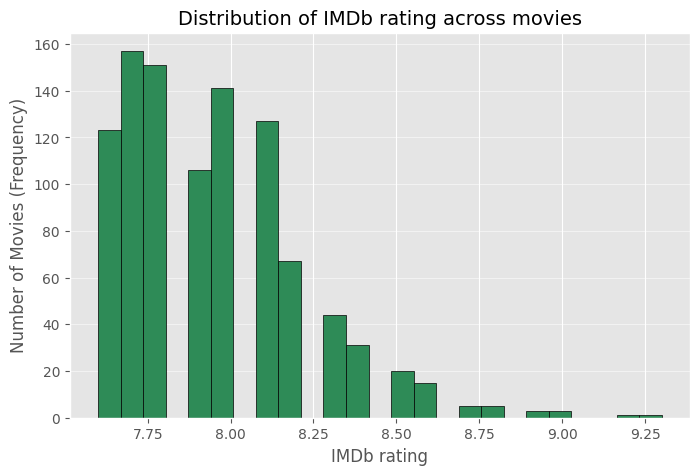

In [50]:
plt.figure(figsize=(8, 5))

plt.hist(
    df['IMDB_Rating'],
    bins=25,
    edgecolor='black',
    color='seagreen'
)

plt.title('Distribution of IMDb rating across movies', fontsize=14)
plt.xlabel('IMDb rating', fontsize=12)
plt.ylabel('Number of Movies (Frequency)', fontsize=12)
plt.grid(axis='y', alpha=0.5)

plt.show()

**Question 16:** How average IMDb Ratings were changing for each Genre thoughout decades?

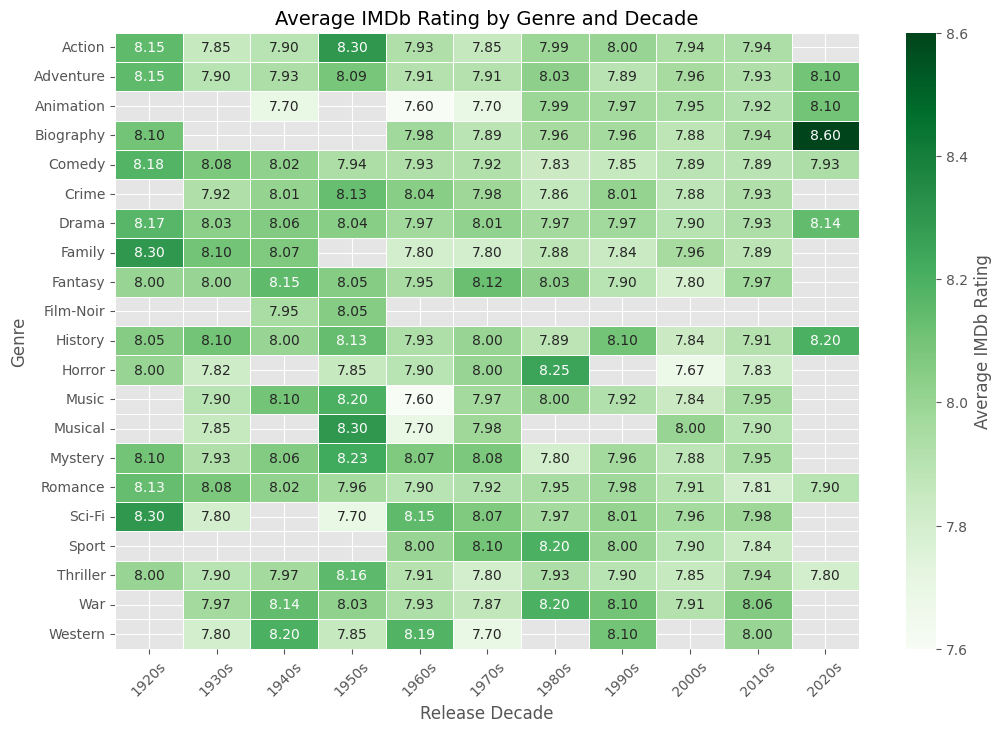

In [51]:
df['Decade'] = (df['Released_Year'] // 10) * 10
df['Decade'] = df['Decade'].astype(str) + 's'

genre_cols = ['Genre_1', 'Genre_2', 'Genre_3']

df_genres = df.melt(
    id_vars=['Decade', 'IMDB_Rating'],
    value_vars=genre_cols,
    value_name='Genre'
).dropna(subset=['Genre'])

final_data = df_genres.groupby(['Decade', 'Genre'])['IMDB_Rating'].mean().reset_index()

heatmap_data = final_data.pivot(index='Genre', columns='Decade', values='IMDB_Rating')
plt.figure(figsize=(12, 8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    linewidths=0.5,
    cbar_kws={'label': 'Average IMDb Rating'}
)

plt.title('Average IMDb Rating by Genre and Decade', fontsize=14)
plt.ylabel('Genre', fontsize=12)
plt.xlabel('Release Decade', fontsize=12)
plt.tick_params(axis='x', rotation=45)

plt.show()

**Question 17:** What is the highest-rated movie in the dataset?

In [52]:
highest_rated_movie = df[df['IMDB_Rating'] == df['IMDB_Rating'].max()]
movie_name = highest_rated_movie['Series_Title'].values[0]
movie_rating = highest_rated_movie['IMDB_Rating'].values[0]

print(f"The highest-rated movie is '{movie_name}' with rating of {movie_rating}.")

The highest-rated movie is 'The Shawshank Redemption' with rating of 9.3.


**Question 18:** Which director has the highest average IMDb Rating across their movies?

In [53]:
directors = df.groupby('Director')['IMDB_Rating'].mean()
directors_sorted = directors.sort_values(ascending=False)
top_director_name = directors_sorted.idxmax()
top_director_rating = directors_sorted.max()

print(f"{top_director_name} has the highest average IMDb rating at {top_director_rating}.")

Frank Darabont has the highest average IMDb rating at 8.95.


**Question 19:** How many movies have both IMDb rating and Metascore available?

In [54]:
imdb_metascore = df['IMDB_Rating'].notna() & df['Meta_score'].notna()
count_both_present = imdb_metascore.sum()

print(f"There are {count_both_present} movies, where both IMDb rating abd Metascore are present.")

There are 843 movies, where both IMDb rating abd Metascore are present.


**Question 20:** How many movies have an IMDb Rating of 8.5 or higher and a Metascore above 85?

In [55]:
high_rated = df[(df['IMDB_Rating'] >= 8.5) & (df['Meta_score'] >= 85)]
high_rated_movies = len(high_rated)

print(f"There are {high_rated_movies} movies with an IMDb rating of 8.5 or higher and a Metascore of 85 or higher.")

There are 29 movies with an IMDb rating of 8.5 or higher and a Metascore of 85 or higher.


**Question 21:** How does the Number of Votes correlate with IMDb Rating?

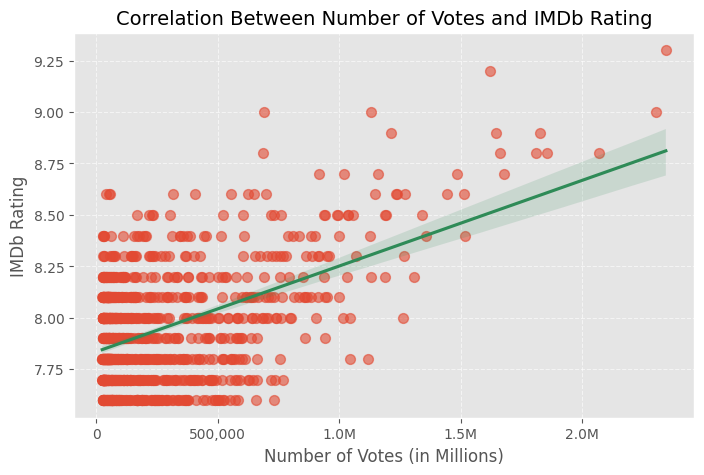

The Spearman correlation coefficient between Number of Votes and IMDb Rating is: 0.2140


In [56]:
correlation = df['No_of_Votes'].corr(df['IMDB_Rating'], method='spearman')

plt.figure(figsize=(8, 5))

ax = sns.regplot(
    x='No_of_Votes',
    y='IMDB_Rating',
    data=df,
    scatter_kws={'alpha': 0.6, 's': 50},
    line_kws={'color': 'seagreen'}
)

ax.xaxis.set_major_formatter(formatter)

plt.title('Correlation Between Number of Votes and IMDb Rating', fontsize=14)
plt.xlabel('Number of Votes (in Millions)', fontsize=12)
plt.ylabel('IMDb Rating', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

print(f"The Spearman correlation coefficient between Number of Votes and IMDb Rating is: {correlation:.4f}")

**Note:**
Since data is not normally distributed Spearman correlation method was selected.

The correlation coefficient of 0.2140 between the Number of Votes and IMDb Rating indicates a weak, positive monotonic relationship between the two variables.

The relationship is based on the ranks of the data, meaning that as the rank of one variable increases, the rank of the other variable tends to increase, but not necessarily in a perfectly linear fashion.

Such correlation coefficient suggests that movies with a higher number of votes tend to have a slightly higher IMDb rating, and vice versa.

While a higher vote count is associated with a better rating, the relationship is weak, meaning vote count is not a strong predictor of the rating itself.

**Question 22:** What is the most common movie certificate in the dataset?

In [57]:
most_common_certificate = df['Certificate'].value_counts().idxmax()
most_common_grouped_certificate = df['Grouped_Certificate'].value_counts().idxmax()

print(f"The most common certificate in original dataset is '{most_common_certificate}', while the most common grouped certificate is '{most_common_grouped_certificate}'.")


The most common certificate in original dataset is 'U', while the most common grouped certificate is 'Parental_Guidance'.


**Question 23:** How certificate types were changing throughout decades?

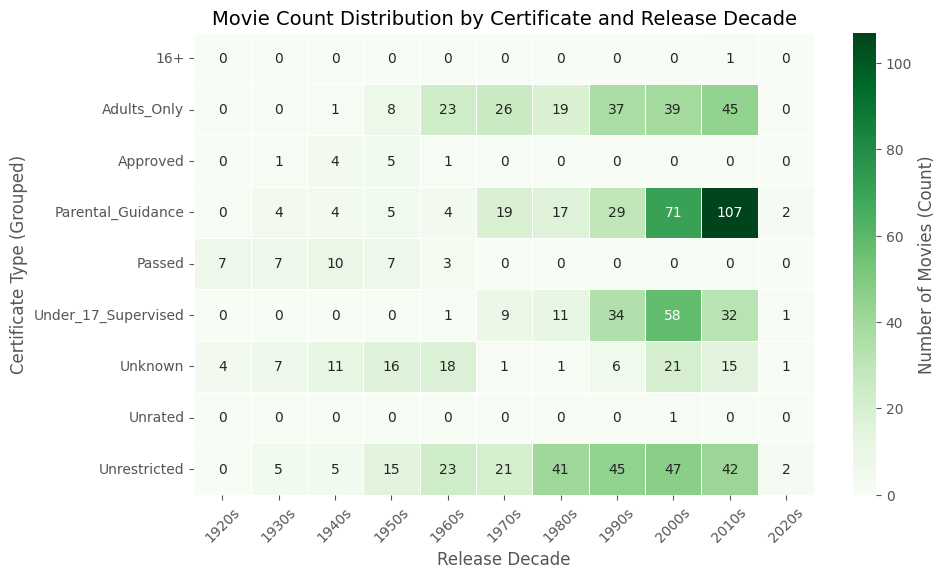

In [58]:
heatmap_count_data = (
    df.groupby(['Grouped_Certificate', 'Decade'])
    .size()
    .unstack(fill_value=0)
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    heatmap_count_data,
    annot=True,
    fmt="d",
    cmap="Greens",
    linewidths=0.5,
    cbar_kws={'label': 'Number of Movies (Count)'}
)

plt.title('Movie Count Distribution by Certificate and Release Decade', fontsize=14)
plt.ylabel('Certificate Type (Grouped)', fontsize=12)
plt.xlabel('Release Decade', fontsize=12)
plt.tick_params(axis='x', rotation=45)

plt.show()

**Question 24:** What is the average Runtime of movies in the dataset?

In [59]:
avg_runtime = df['Runtime_minutes'].mean()

print(f"Average runtime of movies is {avg_runtime:.1f} minutes.")

Average runtime of movies is 122.9 minutes.


**Question 25:** How movie durations are distributed in a dataset?

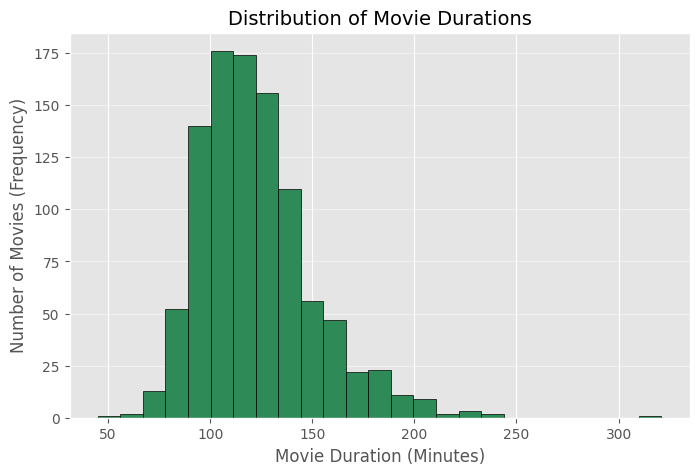

In [60]:
plt.figure(figsize=(8, 5))

plt.hist(
    df['Runtime_minutes'],
    bins=25,
    edgecolor='black',
    color='seagreen'
)

plt.title('Distribution of Movie Durations', fontsize=14)
plt.xlabel('Movie Duration (Minutes)', fontsize=12)
plt.ylabel('Number of Movies (Frequency)', fontsize=12)
plt.grid(axis='y', alpha=0.5)

plt.show()

**Question 26:** Are movies with a longer runtime generally rated higher?

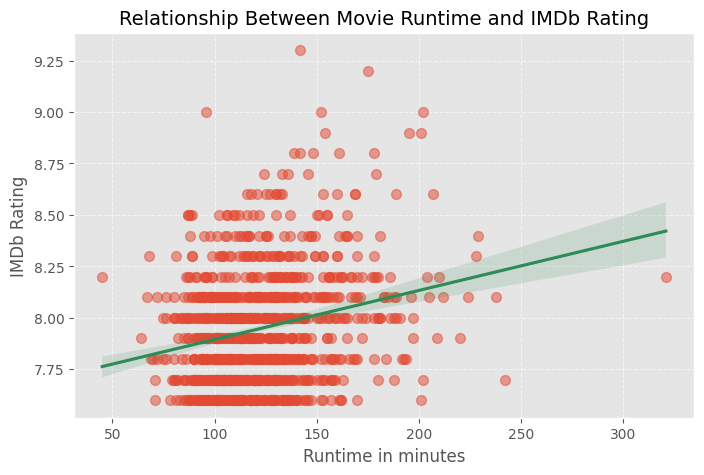

The Spearman correlation coefficient between Runtime and IMDb Rating is: 0.2116


In [61]:
runtime_rating_correlation = df['Runtime_minutes'].corr(df['IMDB_Rating'], method='spearman')

plt.figure(figsize=(8, 5))

sns.regplot(
    x='Runtime_minutes',
    y='IMDB_Rating',
    data=df,
    scatter_kws={'alpha': 0.5, 's': 50},
    line_kws={'color': 'seagreen'}
)

plt.title('Relationship Between Movie Runtime and IMDb Rating', fontsize=14)
plt.xlabel('Runtime in minutes', fontsize=12)
plt.ylabel('IMDb Rating', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"The Spearman correlation coefficient between Runtime and IMDb Rating is: {runtime_rating_correlation:.4f}")

**Note:** The weak positive correlation (r=0.2116) suggests that movies with a longer runtime tend to receive only marginally higher IMDb ratings. So, movies with longer runtime do not generally rated higher.

**Question 27:** What are the top five highest-grossing movies?

In [62]:
successfull_movies = df.nlargest(5, 'Gross')

print("Top 5 movies by grossing in the dataset are:")
count = 1
for movie in successfull_movies['Series_Title']:
    print(f"{count}. {movie}")
    count += 1

Top 5 movies by grossing in the dataset are:
1. Star Wars: Episode VII - The Force Awakens
2. Avengers: Endgame
3. Avatar
4. Avengers: Infinity War
5. Titanic


**Question 28:** How total grossing was changing throughout decades?

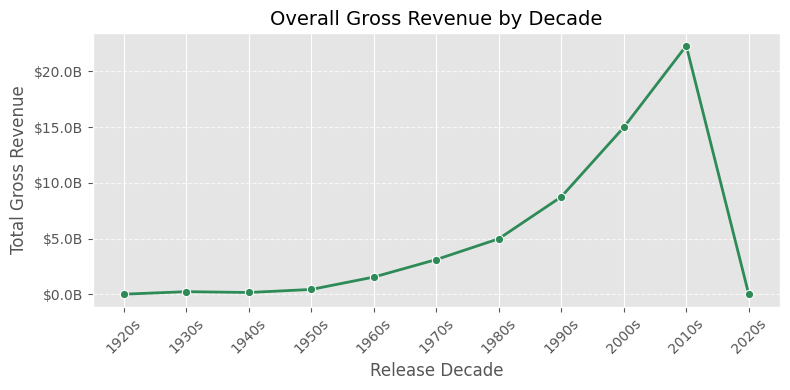

In [63]:
gross_by_decade = df.groupby('Decade')['Gross'].sum().sort_index()

plot_data = gross_by_decade.reset_index()

plt.figure(figsize=(8, 4))

sns.lineplot(
    x='Decade',
    y='Gross',
    data=plot_data,
    marker='o',
    color='seagreen',
    linewidth=2
)

def billions_formatter(x, pos):
    return f'${x / 10**9:.1f}B'

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(billions_formatter))

plt.title('Overall Gross Revenue by Decade', fontsize=14)
plt.xlabel('Release Decade', fontsize=12)
plt.ylabel('Total Gross Revenue', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

**Question 29:** Which Genre has the highest average Gross Revenue?

In [64]:
genre_cols = ['Genre_1', 'Genre_2', 'Genre_3']

df_melted = df.melt(
    id_vars=['Gross'],
    value_vars=genre_cols,
    value_name='Genre'
).dropna(subset=['Genre'])

successfull_genres = df_melted.groupby('Genre')['Gross'].mean()

successfull_genre = successfull_genres.idxmax()
average_gross = successfull_genres.max()

print(f"'{successfull_genre}' genre has the highest average grossing: ${average_gross:,.2f}.")

'Adventure' genre has the highest average grossing: $165,731,278.64.


**Note:** Average grossing includes movies that belong to more than 1 genre.

**Question 30:** What is the average Gross Revenue for movies directed by the top 10 directors with the most movies?

In [65]:
top_10_directors = productive_directors[:10]
top_10_director_names = top_10_directors.index

df_top_10 = df[df['Director'].isin(top_10_director_names)]
avg_gross_top_10 = df_top_10['Gross'].mean()

print(f"Average gross revenue for movies directed by the top 10 directors with most movies: ${avg_gross_top_10:,.2f}.")

Average gross revenue for movies directed by the top 10 directors with most movies: $64,807,906.33.


**Question 31:** What is the relationship between Number of Votes and Gross Revenue of a movie?

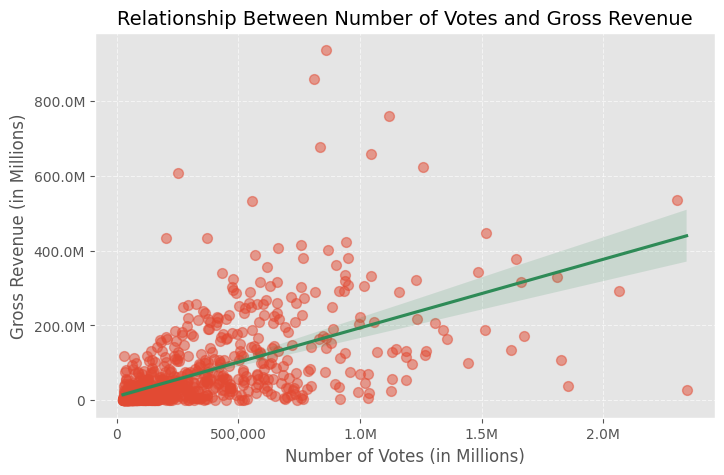

The Spearman correlation coefficient between Number of Votes and Gross Revenue is: 0.6991


In [66]:
votes_gross_correlation = df['No_of_Votes'].corr(df['Gross'], method ='spearman')

plt.figure(figsize=(8, 5))

ax = sns.regplot(
    x='No_of_Votes',
    y='Gross',
    data=df,
    scatter_kws={'alpha': 0.5, 's': 50},
    line_kws={'color': 'seagreen'}
)

ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

plt.title('Relationship Between Number of Votes and Gross Revenue', fontsize=14)
plt.xlabel('Number of Votes (in Millions)', fontsize=12)
plt.ylabel('Gross Revenue (in Millions)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"The Spearman correlation coefficient between Number of Votes and Gross Revenue is: {votes_gross_correlation:.4f}")

**Note:** A Spearman correlation coefficient (r=0.6991) between the Number of Votes and Gross Revenue indicates a moderately strong, positive monotonic relationship. In practical terms, movies that receive significantly more votes than others generally earn significantly more revenue than others.

The number of votes on the platform is a relatively good indicator of a movie's financial success. This suggests that movies generating high audience interest are often, though not perfectly, rewarded with high box office earnings.

**Question 32:** What is the relationship between IMDb Rating and Director?

In [67]:
director_counts = df['Director'].value_counts()
relevant_directors = director_counts[director_counts > 3].index

df_filtered = df[df['Director'].isin(relevant_directors)]

ratings_by_director = [
    df_filtered['IMDB_Rating'][df_filtered['Director'] == director].dropna()
    for director in relevant_directors
]

if len(ratings_by_director) < 2:
    print("Error: Not enough director groups (must be at least 2) after filtering.")
else:
    h_statistic, p_value = stats.kruskal(*ratings_by_director)

    print("\n--- Kruskal-Wallis H Test for Director's Impact on IMDB Rating ---")
    print(f"Number of Directors Tested: {len(relevant_directors)}")
    print(f"H-Statistic: {h_statistic:.4f}")
    print(f"p-value: {p_value:.4f}")

    if p_value < 0.05:
        print("\nConclusion: Reject Null Hypothesis.")
        print("There is a statistically significant difference in the median IMDb Rating across the tested directors.")
    else:
        print("\nConclusion: Fail to Reject Null Hypothesis.")
        print("There is no statistically significant difference in the median IMDb Rating across the tested directors.")


--- Kruskal-Wallis H Test for Director's Impact on IMDB Rating ---
Number of Directors Tested: 54
H-Statistic: 102.7348
p-value: 0.0001

Conclusion: Reject Null Hypothesis.
There is a statistically significant difference in the median IMDb Rating across the tested directors.


**Note:** The Kruskal-Wallis H Test (H=102.73,p=0.0001) indicated that the median IMDb ratings across the 54 tested directors (those with more than 3 films) are not all equal.

In [68]:
dunn_results = sp.posthoc_dunn(
    ratings_by_director,
    p_adjust='fdr_bh'
)

dunn_results.columns = relevant_directors
dunn_results.index = relevant_directors

significant_p_values = dunn_results[dunn_results < 0.05]

significant_pairs = significant_p_values.stack()

print("\n--- Statistically Significant Director Pair Differences (p < 0.05) ---")
print(f"Total number of significant differences found: {len(significant_pairs) // 2}")
print("Director Pair (Row, Column) | Benjamini-Hochberg Corrected P-Value")
print("---------------------------------------------------------------")
print(significant_pairs.to_string())


--- Statistically Significant Director Pair Differences (p < 0.05) ---
Total number of significant differences found: 8
Director Pair (Row, Column) | Benjamini-Hochberg Corrected P-Value
---------------------------------------------------------------
Director           Director         
Akira Kurosawa     Matthew Vaughn       0.049414
Stanley Kubrick    Matthew Vaughn       0.049414
Woody Allen        Christopher Nolan    0.038930
                   Charles Chaplin      0.049414
Christopher Nolan  Woody Allen          0.038930
                   Alfonso Cuarón       0.042473
                   Matthew Vaughn       0.038930
                   Spike Lee            0.049414
Charles Chaplin    Woody Allen          0.049414
                   Matthew Vaughn       0.042473
Alfonso Cuarón     Christopher Nolan    0.042473
Matthew Vaughn     Akira Kurosawa       0.049414
                   Stanley Kubrick      0.049414
                   Christopher Nolan    0.038930
                   Charle

**Note:** The Dunn's post-hoc test (with Benjamini-Hochberg correction) identified 8 unique pairs of directors whose median IMDb ratings are significantly different from one another.

The majority of the significant differences involve a few highly distinguishable directors:

- Matthew Vaughn's filmography median rating is significantly different from that of four other directors, including classics like Akira Kurosawa and Stanley Kubrick, and contemporary directors like Christopher Nolan.

- Christopher Nolan's median rating is significantly different from four other directors, including Woody Allen and Alfonso Cuarón.

The results confirm that the performance of some modern directors is statistically distinct from both peers and classical filmmakers in terms of median IMDb ratings.

**Question 33:** What is the relationship between the Gross Revenue of a movie and its Director?

In [69]:
gross_by_director = [
    df_filtered['Gross'][df_filtered['Director'] == director].dropna()
    for director in relevant_directors
]

if len(gross_by_director) < 2:
    print("Error: Not enough director groups (must be at least 2) after filtering.")
else:
    h_statistic, p_value = stats.kruskal(*gross_by_director)

    print("\n--- Kruskal-Wallis H Test for Director's Impact on Gross Revenue ---")
    print(f"Number of Directors Tested: {len(relevant_directors)}")
    print(f"H-Statistic: {h_statistic:.4f}")
    print(f"p-value: {p_value:.4f}")

    if p_value < 0.05:
        print("\nConclusion: Reject Null Hypothesis.")
        print("There is a statistically significant difference in the median Gross Revenue across the tested directors.")
    else:
        print("\nConclusion: Fail to Reject Null Hypothesis.")
        print("There is no statistically significant difference in the median Gross Revenue across the tested directors.")


--- Kruskal-Wallis H Test for Director's Impact on Gross Revenue ---
Number of Directors Tested: 54
H-Statistic: 196.8346
p-value: 0.0000

Conclusion: Reject Null Hypothesis.
There is a statistically significant difference in the median Gross Revenue across the tested directors.


**Note:** The Kruskal-Wallis test result indicates that the Director's identity has a highly statistically significant impact on a movie's median Gross Revenue. To explore this impact Dunn's post-hoc test follows.

In [70]:
dunn_results = sp.posthoc_dunn(
    gross_by_director,
    p_adjust='fdr_bh'
)

dunn_results.columns = relevant_directors
dunn_results.index = relevant_directors

significant_p_values = dunn_results[dunn_results < 0.05]

significant_pairs = significant_p_values.stack()

print("\n--- Statistically Significant Director Pair Differences (p < 0.05) ---")
print(f"Total number of significant differences found: {len(significant_pairs) // 2}")
print("Director Pair (Row, Column) | Benjamini-Hochberg Corrected P-Value")
print("---------------------------------------------------------------")
print(significant_pairs.to_string())


--- Statistically Significant Director Pair Differences (p < 0.05) ---
Total number of significant differences found: 279
Director Pair (Row, Column) | Benjamini-Hochberg Corrected P-Value
---------------------------------------------------------------
Director              Director            
Alfred Hitchcock      Steven Spielberg        0.003402
                      David Fincher           0.043980
                      Christopher Nolan       0.005987
                      Ridley Scott            0.026908
                      Peter Jackson           0.003589
                      Robert Zemeckis         0.009030
                      James Cameron           0.015646
                      Sam Mendes              0.022542
                      Brad Bird               0.027860
                      Anthony Russo           0.004601
                      Pete Docter             0.011731
                      James Mangold           0.047240
Steven Spielberg      Alfred Hitchcock     

**Note:** The high number of significant differences (279) indicates that Gross Revenue is highly stratified by Director. The disparity is not just between a few outliers but forms extensive clusters of directors with statistically distinct financial performance. The results strongly suggest the existence of different groups of directors based on their revenue performance:
- **The High-Revenue Cluster (The Blockbuster Architects):** Steven Spielberg, Christopher Nolan, James Cameron, Peter Jackson, and Anthony Russo appear frequently, showing they typically achieve a median gross revenue that is statistically higher than many of their contemporaries and classical peers.
- **The Classical/International Cluster:** Directors whose films, though critically acclaimed (as suggested by the earlier IMDb test), have median gross revenues that are significantly lower than the blockbuster cluster. Akira Kurosawa, Hayao Miyazaki, Charles Chaplin, and Andrei Tarkovsky show significant differences with many modern high-grossing directors.



**Question 34:** What is the relationship between IMDb Rating of a movie a particular actor?

In [71]:
star_cols = ['Star1', 'Star2', 'Star3', 'Star4']

df_actors_melted = df.melt(
    id_vars=['IMDB_Rating'],
    value_vars=star_cols,
    value_name='Actor'
).dropna(subset=['Actor'])

actor_counts = df_actors_melted['Actor'].value_counts()
relevant_actors = actor_counts[actor_counts > 3].index

df_filtered = df_actors_melted[df_actors_melted['Actor'].isin(relevant_actors)]

ratings_by_actor = [
    df_filtered['IMDB_Rating'][df_filtered['Actor'] == actor].dropna()
    for actor in relevant_actors
]

if len(ratings_by_actor) < 2:
    print("Error: Not enough actor groups (must be at least 2) after filtering.")
else:
    h_statistic, p_value = stats.kruskal(*ratings_by_actor)

    print("\n--- Kruskal-Wallis H Test for Actor's Impact on IMDB Rating ---")
    print(f"Number of Actors Tested: {len(relevant_actors)}")
    print(f"H-Statistic: {h_statistic:.4f}")
    print(f"p-value: {p_value:.4f}")

    if p_value < 0.05:
        print("\nConclusion: Reject Null Hypothesis.")
        print("There is a statistically significant difference in the median IMDb Rating across the tested actors.")
    else:
        print("\nConclusion: Fail to Reject Null Hypothesis.")
        print("There is no statistically significant difference in the median IMDb Rating across the tested actors.")


--- Kruskal-Wallis H Test for Actor's Impact on IMDB Rating ---
Number of Actors Tested: 145
H-Statistic: 224.1491
p-value: 0.0000

Conclusion: Reject Null Hypothesis.
There is a statistically significant difference in the median IMDb Rating across the tested actors.


**Note:** The Kruskal-Wallis H Test result suggests that the actor's identity is a statistically significant factor influencing a movie's median IMDb rating. The Dunn's post-hoc test follows.

In [72]:
if len(ratings_by_actor) < 2:
    print("Error: Not enough actor groups (must be at least 2) after filtering.")
else:
    dunn_results = sp.posthoc_dunn(
        ratings_by_actor,
        p_adjust='fdr_bh'
    )

    dunn_results.columns = relevant_actors
    dunn_results.index = relevant_actors

    significant_p_values = dunn_results[dunn_results < 0.05]
    significant_pairs = significant_p_values.stack()

    print("\n--- Statistically Significant Actor Pair Differences (p < 0.05) ---")
    if not significant_pairs.empty:
        print(f"Total number of unique significant differences found: {len(significant_pairs) // 2}")
        print("Actor Pair (Row, Column) | FDR Corrected P-Value")
        print("---------------------------------------------------------------")
        print(significant_pairs.to_string())
    else:
        print("No significant pairwise differences found using the FDR correction.")


--- Statistically Significant Actor Pair Differences (p < 0.05) ---
No significant pairwise differences found using the FDR correction.


**Note:** The analysis, which examined 145 relevant actors, revealed that while the actor's identity is a statistically significant factor overall, it does not translate into specific, measurable differences between individual actors.

It means that no single actor or pair of actors has a median IMDb rating that is statistically unique or significantly higher/lower than all their peers.

**Question 35:** What is the relationship between IMDb Rating of a movie a particular actor?

In [73]:
star_cols = ['Star1', 'Star2', 'Star3', 'Star4']

df_actors_melted = df.melt(
    id_vars=['Gross'],
    value_vars=star_cols,
    value_name='Actor'
).dropna(subset=['Actor'])

actor_counts = df_actors_melted['Actor'].value_counts()
relevant_actors = actor_counts[actor_counts > 3].index

df_filtered = df_actors_melted[df_actors_melted['Actor'].isin(relevant_actors)]

gross_by_actor = [
    df_filtered['Gross'][df_filtered['Actor'] == actor].dropna()
    for actor in relevant_actors
]

if len(ratings_by_actor) < 2:
    print("Error: Not enough actor groups (must be at least 2) after filtering.")
else:
    h_statistic, p_value = stats.kruskal(*gross_by_actor)

    print("\n--- Kruskal-Wallis H Test for Actor's Impact on IMDB Rating ---")
    print(f"Number of Actors Tested: {len(relevant_actors)}")
    print(f"H-Statistic: {h_statistic:.4f}")
    print(f"p-value: {p_value:.4f}")

    if p_value < 0.05:
        print("\nConclusion: Reject Null Hypothesis.")
        print("There is a statistically significant difference in the median Gross Revenue the tested actors.")
    else:
        print("\nConclusion: Fail to Reject Null Hypothesis.")
        print("There is no statistically significant difference in the median Gross Revenue the tested actors.")


--- Kruskal-Wallis H Test for Actor's Impact on IMDB Rating ---
Number of Actors Tested: 145
H-Statistic: 399.8181
p-value: 0.0000

Conclusion: Reject Null Hypothesis.
There is a statistically significant difference in the median Gross Revenue the tested actors.


**Note:** The Kruskal-Wallis H Test strongly supports the idea that the lead actor is a significant factor in a film's box office success.

In [74]:
if len(gross_by_actor) < 2:
    print("Error: Not enough actor groups (must be at least 2) after filtering.")
else:
    dunn_results = sp.posthoc_dunn(
        gross_by_actor,
        p_adjust='fdr_bh'
    )

    dunn_results.columns = relevant_actors
    dunn_results.index = relevant_actors

    significant_p_values = dunn_results[dunn_results < 0.05]
    significant_pairs = significant_p_values.stack()

    print("\n--- Statistically Significant Actor Pair Differences (p < 0.05) ---")
    if not significant_pairs.empty:
        print(f"Total number of unique significant differences found: {len(significant_pairs) // 2}")
        print("Actor Pair (Row, Column) | FDR Corrected P-Value")
        print("---------------------------------------------------------------")
        print(significant_pairs.to_string())
    else:
        print("No significant pairwise differences found using the FDR correction.")


--- Statistically Significant Actor Pair Differences (p < 0.05) ---
Total number of unique significant differences found: 791
Actor Pair (Row, Column) | FDR Corrected P-Value
---------------------------------------------------------------
Actor                   Actor                 
Robert De Niro          Tom Hanks                 0.016159
                        Robert Downey Jr.         0.019890
                        Ian McKellen              0.031182
                        Rupert Grint              0.016159
                        Daniel Radcliffe          0.016159
                        Tim Allen                 0.043094
                        Zoe Saldana               0.031501
                        Orlando Bloom             0.031677
                        Joe Russo                 0.024487
Tom Hanks               Robert De Niro            0.016159
                        Al Pacino                 0.035841
                        Clint Eastwood            0.027406
     

**Note:** The post-hoc test confirms the overall statistical significance by identifying 791 unique pairs of actors whose median gross revenues are statistically distinguishable after controlling for the False Discovery Rate (FDR).

The majority of the significant differences are driven by a cluster of actors associated with high-budget, global blockbuster franchises.

- Robert Downey Jr. (Iron Man/Avengers): Shows differences with 29 other actors, his association with massive franchises elevates his median revenue performance far beyond most others.

- Tom Hanks and Tom Cruise are also heavily involved, demonstrating their strong, consistent box office power across genres and decades.

## **EDA Summary**

*   **Overall observations**

This dataset comprises **1000 movies** spanning across **21 genres** and featuring **548 directors**. The dataset presents the most high-rated movies on IMDb platform, covering films released between **1920** and **2020**. The movie count per decade shows a clear trend of increasing releases over time, peaking after the year **2000**.

The average movie runtime is **122.9 minutes**.

***

*   **Popular genres, directors and actors**

The genre distribution is dominated by **Drama** (**724 movies**), followed by **Comedy** (**233 movies**) and **Crime** (**209 movies**). The vast majority of movies are multi-genre.

**Alfred Hitchcock** is the most frequent director with **14 movies** in the dataset.

**Robert De Niro** leads the overall actor count with **17 movies**. Looking at specific star roles, **Tom Hanks** is most often featured as 'Star1' (**12 times**), **Emma Watson** as 'Star2' (**7 times**), and **Rupert Grint** as 'Star3' (**5 times**).

***

*   **Ratings, Revenue, and Runtime Analysis**

The overall average IMDb rating for movies in the dataset is **7.95**. The highest-rated movie is **'The Shawshank Redemption'** (**9.3**). **Frank Darabont** has the highest average rating among directors (**8.95**). A small subset of **29 movies** achieved both a high IMDb rating ($\ge 8.5$) and a high Metascore ($\ge 85$).

The **Adventure** genre boasts the highest average grossing ($165,731,278.64), and the movies with highest grossings are **'Star Wars: Episode VII - The Force Awakens'** and **'Avengers: Endgame'**.

A **weak, positive monotonic relationship** was found between **Number of Votes and IMDb Rating** (Spearman $\rho = 0.2140$). This suggests movies with higher vote counts tend to have slightly higher ratings, but vote count is not a strong predictor.

A similarly **weak positive correlation** exists between **Runtime and IMDb Rating** (Spearman $\rho = 0.2116$). While longer movies tend to receive marginally higher ratings, runtime is not a primary factor.

The analysis of financial performance reveals **moderately strong relationships** between audience interest, as measured by votes, and box office earnings, while highlighting the **profound influence of the Director's identity** on a movie's gross revenue.

A **moderately strong, positive monotonic relationship** was found between the **Number of Votes and Gross Revenue** (Spearman $\rho = 0.6991$). This indicates that movies receiving significantly more votes generally earn significantly more revenue. The number of votes serves as a relatively good indicator of a movie's financial success.

The Director's identity has a **highly statistically significant impact** on a movie's median Gross Revenue, confirming that revenue is heavily **stratified by Director**. The **279 significant differences** found in the post-hoc test suggest the financial disparity is extensive, forming distinct performance clusters. This distinction underscores a separation between critical acclaim/historical significance and modern commercial success.

The result of Dunn's post-hoc test strongly suggests that median **IMDb rating** is influenced by a complex set of movie-specific factors (director, writing, genre, year, studio marketing) rather than being consistently driven by a lead actor's star power or reputation.

The **actor's name** is a very powerful variable in determining median **Gross Revenue**. Unlike the IMDb rating, in financial terms, hiring an actor from the "Robert Downey Jr. tier" is statistically associated with a vastly different (and likely higher) median financial outcome than hiring an actor from the "Humphrey Bogart tier."

Simultaneously, many classic and international actors known for critical depth show significantly lower median gross revenue compared to modern global stars.

**Limitations:**

*  This analysis included all movies of original dataset.

- Some calculations depend on the fact that many movies in dataset belong to several genres.

- Movies with low gross revenue (< $100,000) can distort calculations of gross revenues.